In [30]:
!pip install ucimlrepo

In [31]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, confusion_matrix



In [32]:
# Fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# Features and target
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# Convert to DataFrame if not already
X = pd.DataFrame(X)
y = pd.Series(y.values.ravel(), name="diagnosis")

# --- CLEANING & PREPROCESSING ---

In [33]:
# 1. Check basic info
print("Initial Data Information:")
print(X.info())
print("\nMissing values count:\n", X.isnull().sum())

# 2. Handle missing values (if any) - usually none in this dataset
X = X.dropna()

# 3. Encode target (M=1, B=0)
y = y.map({'M':1, 'B':0})

Initial Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-nul

In [34]:
# 4. Train-test split (maintain stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 5. Standardize features (important for LR, SVM, and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nPreprocessing Complete!")
print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)


Preprocessing Complete!
Train shape: (455, 30)
Test shape: (114, 30)



X_train_scaled, X_test_scaled → for training Logistic Regression, SVM, KNN.

X_train, X_test (unscaled) → Useful for Random Forest (scaling not required).

y_train, y_test → Target labels ready to go.

# KNN


In [35]:
sns.set(style="whitegrid")

In [36]:
def evaluate_model(model, X_test, y_test, y_prob):
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    roc  = roc_auc_score(y_test, y_prob)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc:.4f}")

    return y_pred


In [37]:
# --------------------------------------
# KNN Model (k = 5)
# --------------------------------------
knn5 = KNeighborsClassifier(n_neighbors=5)

# 5-fold CV
knn_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn_cv_scores_5 = cross_val_score(knn5, X_train_scaled, y_train, cv=knn_cv, scoring='accuracy')

# Train model
knn5.fit(X_train_scaled, y_train)

# Predictions
knn_y_prob_5 = knn5.predict_proba(X_test_scaled)[:,1]

print("===== KNN (k=5) Performance =====")
knn_y_pred_5 = evaluate_model(knn5, X_test_scaled, y_test, knn_y_prob_5)
print(f"5-Fold CV Accuracy: {knn_cv_scores_5.mean():.4f}")

===== KNN (k=5) Performance =====
Accuracy:  0.9561
Precision: 0.9744
Recall:    0.9048
F1 Score:  0.9383
ROC-AUC:   0.9823
5-Fold CV Accuracy: 0.9670


In [38]:
# --------------------------------------
# KNN Model (k = 10)
# --------------------------------------
knn10 = KNeighborsClassifier(n_neighbors=10)

# 10-fold CV
knn_cv_scores_10 = cross_val_score(knn10, X_train_scaled, y_train, cv=knn_cv, scoring='accuracy')

# Train model
knn10.fit(X_train_scaled, y_train)

# Predictions
knn_y_prob_10 = knn10.predict_proba(X_test_scaled)[:,1]

print("\n===== KNN (k=10) Performance =====")
knn_y_pred_10 = evaluate_model(knn10, X_test_scaled, y_test, knn_y_prob_10)
print(f"10-Fold CV Accuracy: {knn_cv_scores_10.mean():.4f}")


===== KNN (k=10) Performance =====
Accuracy:  0.9474
Precision: 0.9737
Recall:    0.8810
F1 Score:  0.9250
ROC-AUC:   0.9818
10-Fold CV Accuracy: 0.9604


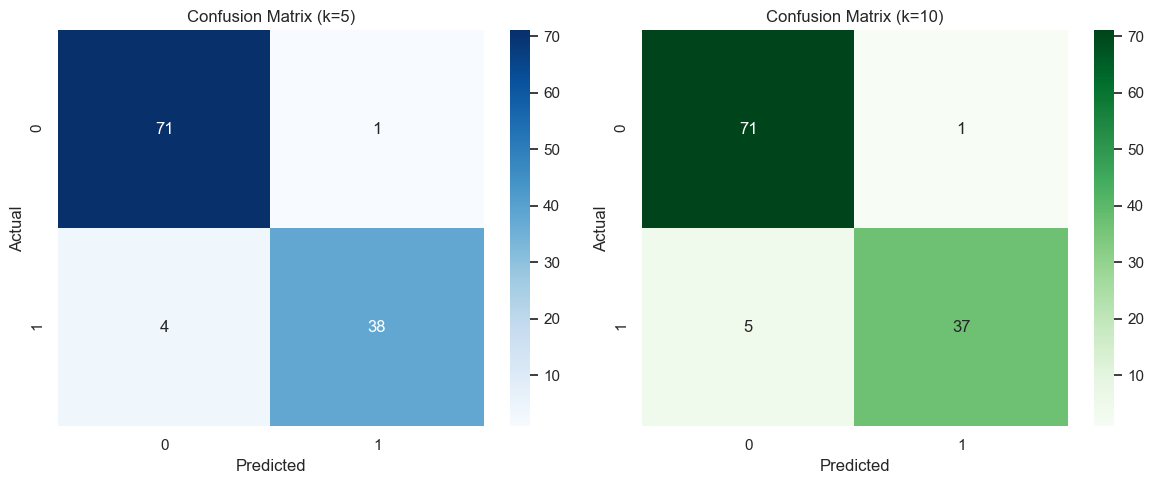

In [39]:
# --------------------------------------
# Confusion Matrices
# --------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12,5))

knn_cm5 = confusion_matrix(y_test, knn_y_pred_5)
knn_cm10 = confusion_matrix(y_test, knn_y_pred_10)

sns.heatmap(knn_cm5, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix (k=5)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(knn_cm10, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Confusion Matrix (k=10)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

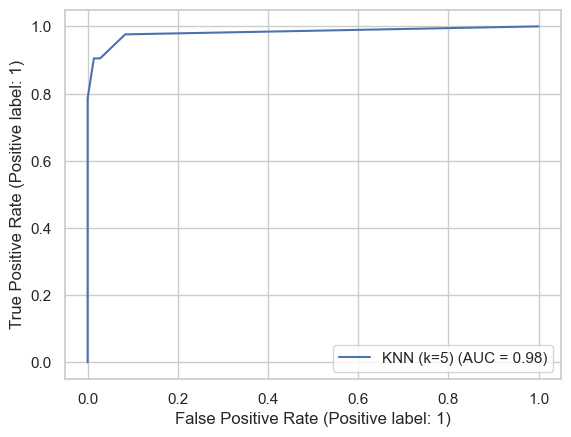

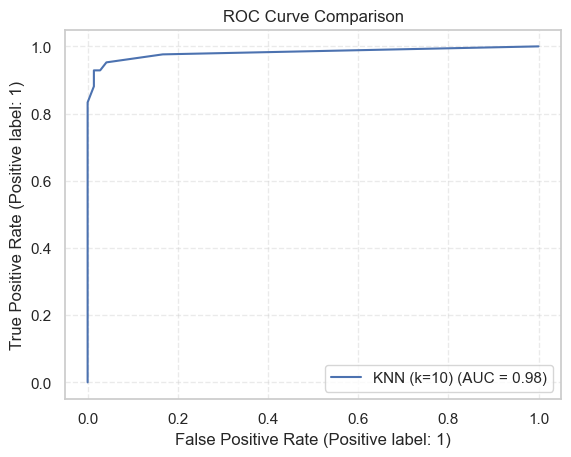

In [40]:
# --------------------------------------
# ROC Curve Comparison
# --------------------------------------
plt.figure(figsize=(8,6))

RocCurveDisplay.from_estimator(knn5, X_test_scaled, y_test, name="KNN (k=5)")
RocCurveDisplay.from_estimator(knn10, X_test_scaled, y_test, name="KNN (k=10)")

plt.title("ROC Curve Comparison")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [41]:
# --------------------------------------
# GridSearchCV - KNN Hyperparameter Tuning
# --------------------------------------

param_grid = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]   # Manhattan, Euclidean
}

knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

knn_grid.fit(X_train_scaled, y_train)

print("\n===== Best Hyperparameters (GridSearchCV) =====")
print(knn_grid.best_params_)
print(f"Best CV Accuracy: {knn_grid.best_score_:.4f}")


===== Best Hyperparameters (GridSearchCV) =====
{'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}
Best CV Accuracy: 0.9692


In [42]:
# --------------------------------------
# 9. Evaluate Best Model from GridSearch
# --------------------------------------
best_knn = knn_grid.best_estimator_
knn_y_prob_best = best_knn.predict_proba(X_test_scaled)[:,1]

print("\n===== Best Tuned KNN Performance =====")
_ = evaluate_model(best_knn, X_test_scaled, y_test, knn_y_prob_best)


===== Best Tuned KNN Performance =====
Accuracy:  0.9386
Precision: 0.9730
Recall:    0.8571
F1 Score:  0.9114
ROC-AUC:   0.9825


# Random Forest

In [43]:
# --------------------------------
# Train Random Forest
# --------------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [44]:
# --------------------------------
# Predictions
# --------------------------------
rf_y_pred = rf.predict(X_test_scaled)
rf_y_pred_proba = rf.predict_proba(X_test_scaled)[:, 1]

In [45]:
# --------------------------------
# Evaluation Metrics
# --------------------------------
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)
rf_roc_auc = roc_auc_score(y_test, rf_y_pred_proba)

print("====== RANDOM FOREST RESULTS ======")
print(f"Accuracy:      {rf_accuracy:.4f}")
print(f"Precision:     {rf_precision:.4f}")
print(f"Recall:        {rf_recall:.4f}")
print(f"F1 Score:      {rf_f1:.4f}")
print(f"ROC-AUC:       {rf_roc_auc:.4f}")

====== RANDOM FOREST RESULTS ======
Accuracy:      0.9649
Precision:     1.0000
Recall:        0.9048
F1 Score:      0.9500
ROC-AUC:       0.9960


In [46]:
# --------------------------------
# Cross-Validation (K-Fold = 5)
# --------------------------------
rf_cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv_scores5 = cross_val_score(rf, X_train_scaled, y_train, cv=rf_cv5, scoring='accuracy')

print("\n====== 5-FOLD CROSS VALIDATION ======")
print("CV Accuracy Scores:", rf_cv_scores5)
print("Mean CV Accuracy:", np.mean(rf_cv_scores5))
print("Std Dev:", np.std(rf_cv_scores5))


====== 5-FOLD CROSS VALIDATION ======
CV Accuracy Scores: [0.95604396 0.97802198 0.95604396 0.94505495 0.97802198]
Mean CV Accuracy: 0.9626373626373625
Std Dev: 0.01318681318681317


In [47]:
# --------------------------------
# Cross-Validation (K-Fold = 10)
# --------------------------------
rf_cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
rf_cv_scores10 = cross_val_score(rf, X_train_scaled, y_train, cv=rf_cv10, scoring='accuracy')

print("\n====== 10-FOLD CROSS VALIDATION ======")
print("CV Accuracy Scores:", rf_cv_scores10)
print("Mean CV Accuracy:", np.mean(rf_cv_scores10))
print("Std Dev:", np.std(rf_cv_scores10))


====== 10-FOLD CROSS VALIDATION ======
CV Accuracy Scores: [1.         0.91304348 1.         1.         0.95652174 0.95555556
 0.91111111 0.97777778 1.         0.93333333]
Mean CV Accuracy: 0.9647342995169084
Std Dev: 0.03439464253396631


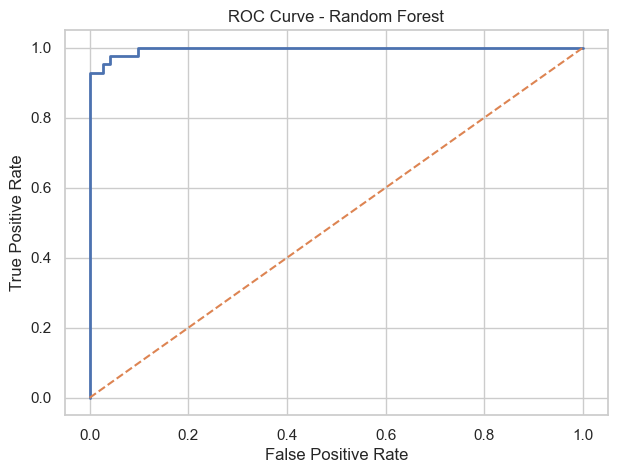

In [48]:
# --------------------------------
# ROC Curve Plot
# --------------------------------
fpr, tpr, _ = roc_curve(y_test, rf_y_pred_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.grid(True)
plt.show()

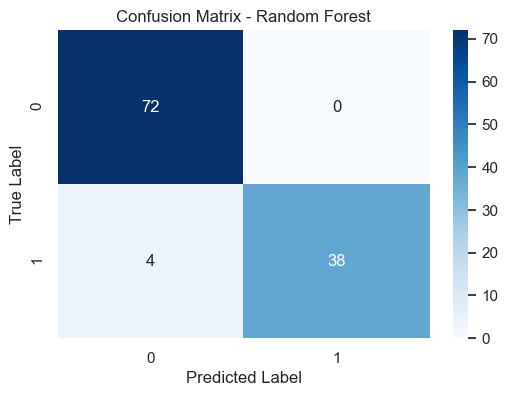

In [49]:
# --------------------------------
# Confusion Matrix
# --------------------------------
rf_cm = confusion_matrix(y_test, rf_y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(rf_cm, annot=True, cmap="Blues", fmt="d")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [50]:
# Reduced, faster parameter grid
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

rf_model = RandomForestClassifier(random_state=42)

rf_grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)

rf_grid_search.fit(X_train_scaled, y_train)

print("===== BEST PARAMETERS FOUND =====")
print(rf_grid_search.best_params_)

print("\n===== BEST SCORE =====")
print(rf_grid_search.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
===== BEST PARAMETERS FOUND =====
{'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

===== BEST SCORE =====
0.9500936113929969


In [51]:
best_rf = rf_grid_search.best_estimator_
best_rf.fit(X_train_scaled, y_train)

rf_y_pred_best = best_rf.predict(X_test_scaled)
rf_y_pred_proba_best = best_rf.predict_proba(X_test_scaled)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_y_pred_best)
rf_precision = precision_score(y_test, rf_y_pred_best)
rf_recall = recall_score(y_test, rf_y_pred_best)
rf_f1 = f1_score(y_test, rf_y_pred_best)
rf_roc_auc = roc_auc_score(y_test, rf_y_pred_proba_best)

print("\n===== FINAL MODEL PERFORMANCE (Optimized RF) =====")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")


===== FINAL MODEL PERFORMANCE (Optimized RF) =====
Accuracy:  0.9737
Precision: 1.0000
Recall:    0.9286
F1 Score:  0.9630
ROC-AUC:   0.9929


In [52]:
# -----------------------------------------------------
# Logistic Regression - Baseline Model
# -----------------------------------------------------
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg_cv_scores = cross_val_score(
    log_reg,
    X_train_scaled,
    y_train,
    cv=log_cv,
    scoring="accuracy"
)

log_reg.fit(X_train_scaled, y_train)
log_reg_y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print("===== Baseline Logistic Regression Performance =====")
log_reg_y_pred = evaluate_model(
    log_reg,
    X_test_scaled,
    y_test,
    log_reg_y_prob
)
print(f"5-Fold CV Accuracy: {log_reg_cv_scores.mean():.4f}")

===== Baseline Logistic Regression Performance =====
Accuracy:  0.9737
Precision: 0.9756
Recall:    0.9524
F1 Score:  0.9639
ROC-AUC:   0.9957
5-Fold CV Accuracy: 0.9714


In [53]:
# -----------------------------------------------------
# Logistic Regression - Hyperparameter Tuning
# -----------------------------------------------------
log_reg_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"]
}

log_reg_grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    param_grid=log_reg_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=1,
    verbose=1
)

log_reg_grid_search.fit(X_train_scaled, y_train)

print("\n===== Best Logistic Regression Parameters =====")
print(log_reg_grid_search.best_params_)
print("Best CV Accuracy:", log_reg_grid_search.best_score_)

best_log_reg = log_reg_grid_search.best_estimator_
best_log_reg_y_prob = best_log_reg.predict_proba(X_test_scaled)[:, 1]

print("\n===== Best Tuned Logistic Regression Performance =====")
best_log_reg_y_pred = evaluate_model(
    best_log_reg,
    X_test_scaled,
    y_test,
    best_log_reg_y_prob
)


Fitting 5 folds for each of 10 candidates, totalling 50 fits

===== Best Logistic Regression Parameters =====
{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Accuracy: 0.9758241758241759

===== Best Tuned Logistic Regression Performance =====
Accuracy:  0.9737
Precision: 0.9756
Recall:    0.9524
F1 Score:  0.9639
ROC-AUC:   0.9831


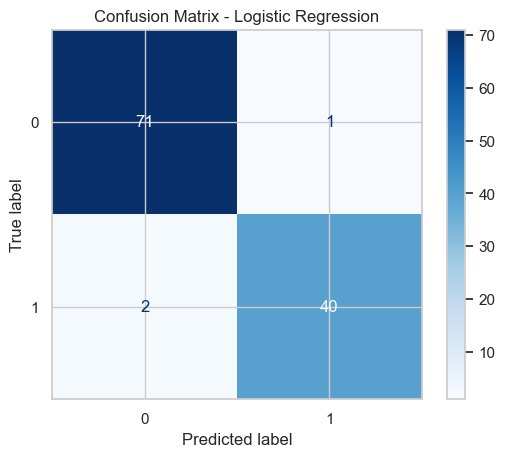

In [54]:
# --------------------------------------
# Confusion Matrix - Logistic Regression
# --------------------------------------

ConfusionMatrixDisplay.from_estimator(
    best_log_reg,
    X_test_scaled,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()


In [55]:
# -----------------------------------------------------
# SVM (RBF) - Baseline Model
# -----------------------------------------------------
svm_clf = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_cv_scores = cross_val_score(
    svm_clf,
    X_train_scaled,
    y_train,
    cv=svm_cv,
    scoring="accuracy"
)

svm_clf.fit(X_train_scaled, y_train)
svm_y_prob = svm_clf.predict_proba(X_test_scaled)[:, 1]

print("\n===== Baseline SVM (RBF) Performance =====")
svm_y_pred = evaluate_model(
    svm_clf,
    X_test_scaled,
    y_test,
    svm_y_prob
)
print(f"5-Fold CV Accuracy: {svm_cv_scores.mean():.4f}")



===== Baseline SVM (RBF) Performance =====
Accuracy:  0.9825
Precision: 0.9762
Recall:    0.9762
F1 Score:  0.9762
ROC-AUC:   0.9954
5-Fold CV Accuracy: 0.9692


In [56]:
# -----------------------------------------------------
# SVM (RBF) - Hyperparameter Tuning
# -----------------------------------------------------
svm_param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto", 0.01, 0.1],
    "kernel": ["rbf"]
}

svm_grid_search = GridSearchCV(
    estimator=SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ),
    param_grid=svm_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=1,
    verbose=1
)

svm_grid_search.fit(X_train_scaled, y_train)

print("\n===== Best SVM Parameters =====")
print(svm_grid_search.best_params_)
print("Best CV Accuracy:", svm_grid_search.best_score_)

best_svm = svm_grid_search.best_estimator_
best_svm_y_prob = best_svm.predict_proba(X_test_scaled)[:, 1]

print("\n===== Best Tuned SVM Performance =====")
best_svm_y_pred = evaluate_model(
    best_svm,
    X_test_scaled,
    y_test,
    best_svm_y_prob
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

===== Best SVM Parameters =====
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV Accuracy: 0.9780219780219781

===== Best Tuned SVM Performance =====
Accuracy:  0.9912
Precision: 1.0000
Recall:    0.9762
F1 Score:  0.9880
ROC-AUC:   0.9970


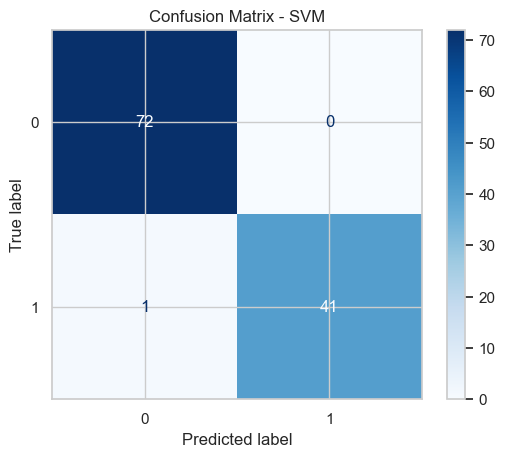

In [57]:
# --------------------------------------
# Confusion Matrix - SVM
# --------------------------------------

ConfusionMatrixDisplay.from_estimator(
    best_svm,
    X_test_scaled,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - SVM")
plt.show()


<Figure size 800x600 with 0 Axes>

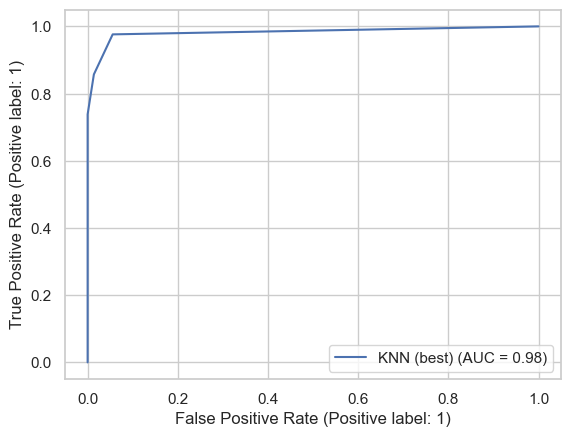

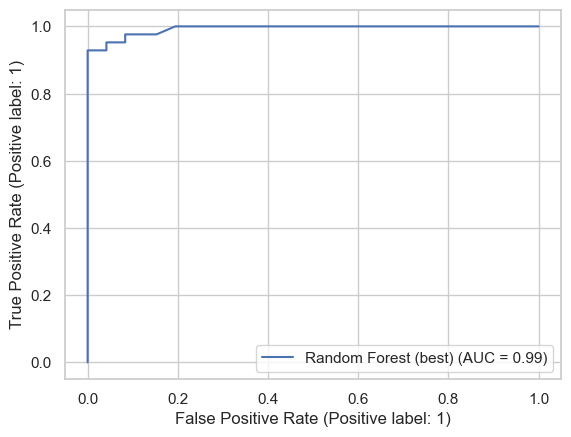

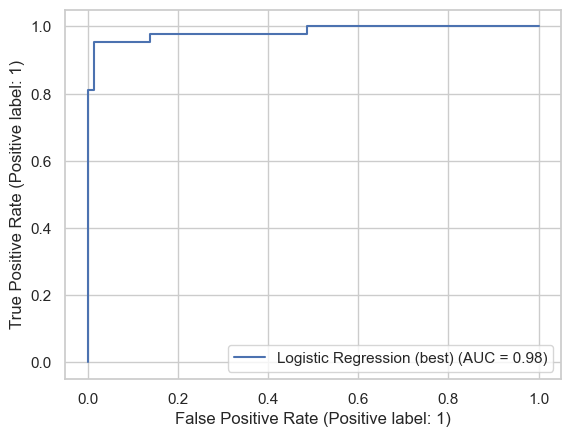

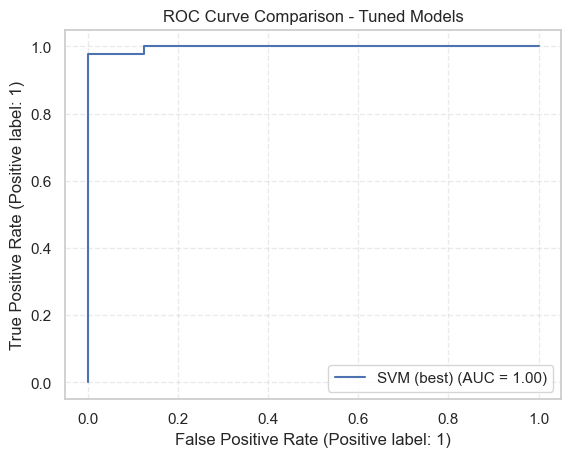

In [58]:
# -----------------------------------------------------
# ROC Curve Comparison - All Tuned Models
# -----------------------------------------------------
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_estimator(
    best_knn,
    X_test_scaled,
    y_test,
    name="KNN (best)"
)
RocCurveDisplay.from_estimator(
    best_rf,
    X_test_scaled,
    y_test,
    name="Random Forest (best)"
)
RocCurveDisplay.from_estimator(
    best_log_reg,
    X_test_scaled,
    y_test,
    name="Logistic Regression (best)"
)
RocCurveDisplay.from_estimator(
    best_svm,
    X_test_scaled,
    y_test,
    name="SVM (best)"
)

plt.title("ROC Curve Comparison - Tuned Models")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()